# 06 — Lattice Structures: SCC, BCC, FCC

**CH4114: Molecular Simulation — Tutorial 00, Part 5**

| | |
|---|---|
| **Course Instructor** | Dr. Susmita Roy |
| **TA / Author** | Shuvam Banerji Seal |

## What you will learn

- The three classic cubic lattices: **SCC**, **BCC**, **FCC**
- How many atoms each unit cell contains, and the atom radius
- 2D top views + 2D packing fractions
- 3D unit cells with Matplotlib (drag to rotate!)
- 3D packing fractions: formula **and** Monte Carlo verification

```mermaid
flowchart TD
    A[Crystal lattice] --> B[SCC: 1 atom/cell, r = a/2]
    A --> C[BCC: 2 atoms/cell, r = a*sqrt3/4]
    A --> D[FCC: 4 atoms/cell, r = a*sqrt2/4]
    B --> E[packing fraction pi/6 = 0.5236]
    C --> F[sqrt3*pi/8 = 0.6802]
    D --> G[pi/(3*sqrt2) = 0.7405]
```

In [1]:
# Cell 1 — imports + signing your code
__author__ = "Shuvam Banerji Seal"   # sign your code — always!

import numpy as np                # for the math
import matplotlib.pyplot as plt   # for the plotting
from mpl_toolkits.mplot3d import Axes3D   # enables 3D axes

%matplotlib inline

## 1. The unit cell

A crystal is a repeating pattern of atoms. The smallest repeating unit is the
**unit cell** — a cube of side `a` (the *lattice constant*).

| Lattice | Atoms per cell | Radius `r` | Coordination |
|---------|---------------:|------------|-------------:|
| SCC | 1 (8 corners × ⅛) | `a/2` | 6 |
| BCC | 2 (8 corners × ⅛ + 1 center) | `a√3/4` | 8 |
| FCC | 4 (8 corners × ⅛ + 6 faces × ½) | `a√2/4` | 12 |

> Why these radii? Neighboring atoms just touch: SCC along the cube **edge**
> (`2r = a`), BCC along the **body diagonal** (`4r = a√3`), FCC along the
> **face diagonal** (`4r = a√2`).

In [2]:
# Helper: atom positions inside the unit cell for each lattice type
A = 1.0   # lattice constant (nm) — we use 1 for simplicity

def unit_cell_atoms(kind):
    """Return (x, y, z) atom coordinates for SCC, BCC or FCC."""
    corners = [(x, y, z) for x in (0, A) for y in (0, A) for z in (0, A)]
    if kind == "SCC":
        return np.array(corners)                     # only the 8 corners
    if kind == "BCC":
        return np.array(corners + [(A/2, A/2, A/2)]) # + 1 body center
    if kind == "FCC":
        faces = [(0, A/2, A/2), (A, A/2, A/2),       # x = 0 and x = A faces
                 (A/2, 0, A/2), (A/2, A, A/2),       # y = 0 and y = A faces
                 (A/2, A/2, 0), (A/2, A/2, A)]       # z = 0 and z = A faces
        return np.array(corners + faces)             # + 6 face centers

for kind in ["SCC", "BCC", "FCC"]:
    print(kind, "->", len(unit_cell_atoms(kind)), "atom positions")

SCC -> 8 atom positions
BCC -> 9 atom positions
FCC -> 14 atom positions


## 2. 2D top views

Looking down the z-axis:
- **SCC** → one atom at each corner of a square
- **BCC** → corners + the body center (seen in the middle)
- **FCC** → corners + the four side-face centers (edge midpoints) + the
  top-face center

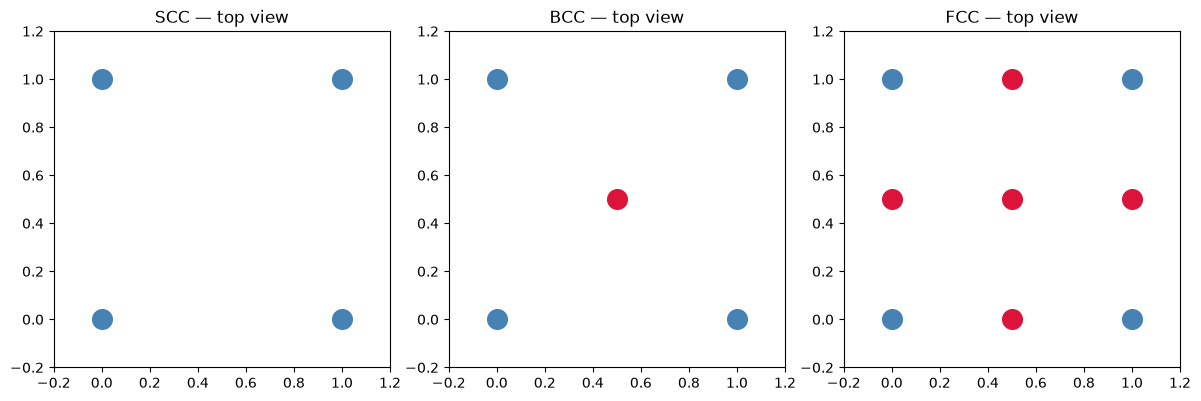

In [3]:
a = 1.0
corners = np.array([[0, 0], [a, 0], [a, a], [0, a]])   # 4 corners of the square

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, name in zip(axes, ["SCC", "BCC", "FCC"]):
    ax.scatter(corners[:, 0], corners[:, 1], s=200, color="steelblue")
    if name == "BCC":
        ax.scatter([a/2], [a/2], s=200, color="crimson")          # body center
    if name == "FCC":
        ax.scatter([a/2, a/2, 0, a, a/2], [0, a, a/2, a/2, a/2],
                   s=200, color="crimson")                        # face centers
    ax.set_title(f"{name} — top view")
    ax.set_xlim(-0.2, 1.2); ax.set_ylim(-0.2, 1.2)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 3. Packing fraction in 2D

**Packing fraction** = area occupied by atoms ÷ total area (atoms = circles).

- Square lattice: cell side `2r`, one circle per cell → `π/4 ≈ 0.7854`
- Hexagonal lattice: the densest 2D packing → `π/(2√3) ≈ 0.9069`

In [4]:
pf_square = np.pi / 4
pf_hex = np.pi / (2 * np.sqrt(3))
print(f"square lattice : {pf_square:.4f}")
print(f"hexagonal      : {pf_hex:.4f}")

square lattice : 0.7854
hexagonal      : 0.9069


## 4. 3D unit cells

Now the real thing: scatter the atoms inside a cube and draw the 12 cube
edges so the cell is visible. **Drag the plot with your mouse to rotate it!**

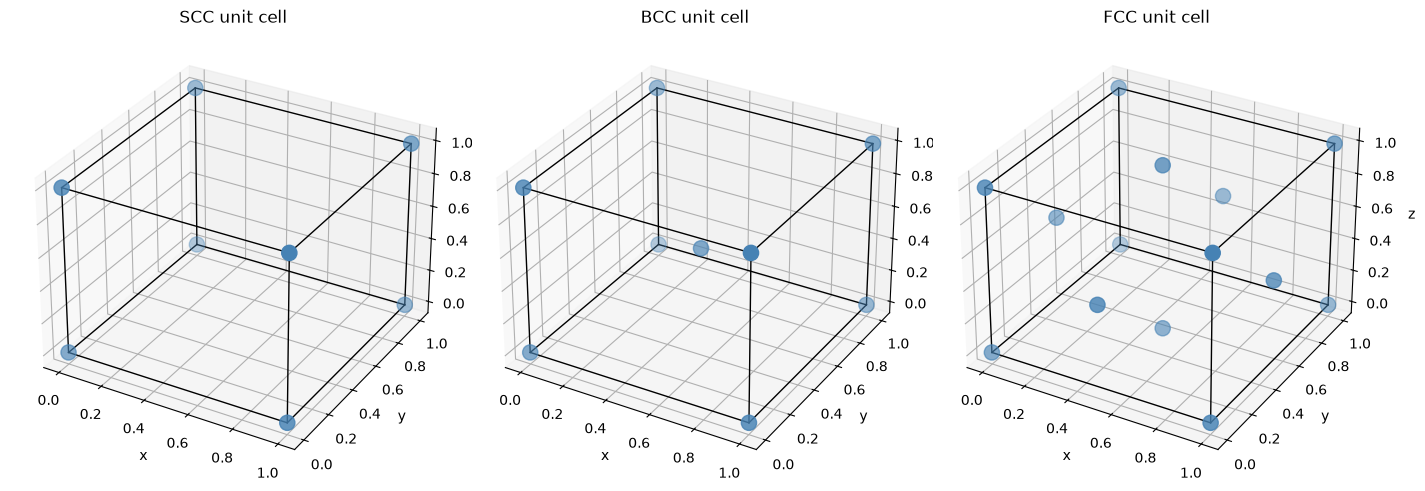

In [5]:
def draw_cube_edges(ax):
    """Draw the 12 edges of the unit cell cube on 3D axes."""
    for x in (0, A):
        for y in (0, A):
            ax.plot([x, x], [y, y], [0, A], color="black", lw=1)
    for x in (0, A):
        for z in (0, A):
            ax.plot([x, x], [0, A], [z, z], color="black", lw=1)
    for y in (0, A):
        for z in (0, A):
            ax.plot([0, A], [y, y], [z, z], color="black", lw=1)

fig = plt.figure(figsize=(14, 5))
for i, kind in enumerate(["SCC", "BCC", "FCC"], start=1):
    ax = fig.add_subplot(1, 3, i, projection="3d")
    atoms = unit_cell_atoms(kind)
    ax.scatter(atoms[:, 0], atoms[:, 1], atoms[:, 2], s=120, color="steelblue")
    draw_cube_edges(ax)
    ax.set_title(f"{kind} unit cell")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.tight_layout()
plt.show()

## 5. Packing fraction in 3D — the formulas

**Packing fraction** = volume of atoms in the cell ÷ volume of the cell.

| Lattice | Atoms | Radius | Packing fraction | Value |
|---------|------:|--------|------------------|------:|
| SCC | 1 | `a/2` | `π/6` | **0.5236** |
| BCC | 2 | `a√3/4` | `√3π/8` | **0.6802** |
| FCC | 4 | `a√2/4` | `π/(3√2)` | **0.7405** |

🏆 FCC is the most efficient packing — that is why many metals (copper, gold,
aluminum) crystallize in FCC.

In [6]:
a = 1.0
pf_scc = (1 * (4/3) * np.pi * (a/2)**3) / a**3
pf_bcc = (2 * (4/3) * np.pi * (a*np.sqrt(3)/4)**3) / a**3
pf_fcc = (4 * (4/3) * np.pi * (a*np.sqrt(2)/4)**3) / a**3

print(f"SCC: {pf_scc:.4f}   BCC: {pf_bcc:.4f}   FCC: {pf_fcc:.4f}")

SCC: 0.5236   BCC: 0.6802   FCC: 0.7405


## 6. Verify with Monte Carlo (random points!)

Throw `N` random points into the cube and count how many fall inside atoms.
The fraction should match the formula — a tiny Monte Carlo simulation, and a
perfect use of `np.random`.

In [7]:
np.random.seed(42)                        # reproducible "random" numbers
N = 200_000                              # number of random points
points = np.random.rand(N, 3) * a        # N points, each (x, y, z) in [0, a]

def inside_any(pts, centers, r):
    """True for points closer than r to ANY atom center."""
    inside = np.zeros(len(pts), dtype=bool)
    for c in centers:
        d = np.sqrt(((pts - c)**2).sum(axis=1))   # distance to this center
        inside = inside | (d < r)                 # mark points inside sphere
    return inside

atoms = unit_cell_atoms("FCC")
r = a * np.sqrt(2) / 4
mc = inside_any(points, atoms, r).mean()
print(f"Monte Carlo FCC packing fraction = {mc:.4f}  (formula: {pf_fcc:.4f})")

Monte Carlo FCC packing fraction = 0.7396  (formula: 0.7405)


## 7. Interactive 3D rotation 🖱️

The plots above are static images. To **rotate them with your mouse** inside
Jupyter, switch to the interactive widget backend (requires `ipympl`):

```
uv add --dev ipympl
```

Run the cell below — in Jupyter the FCC cell becomes draggable; on GitHub
you will see the static version.

Interactive mode ON — drag the 3D plot to rotate it!


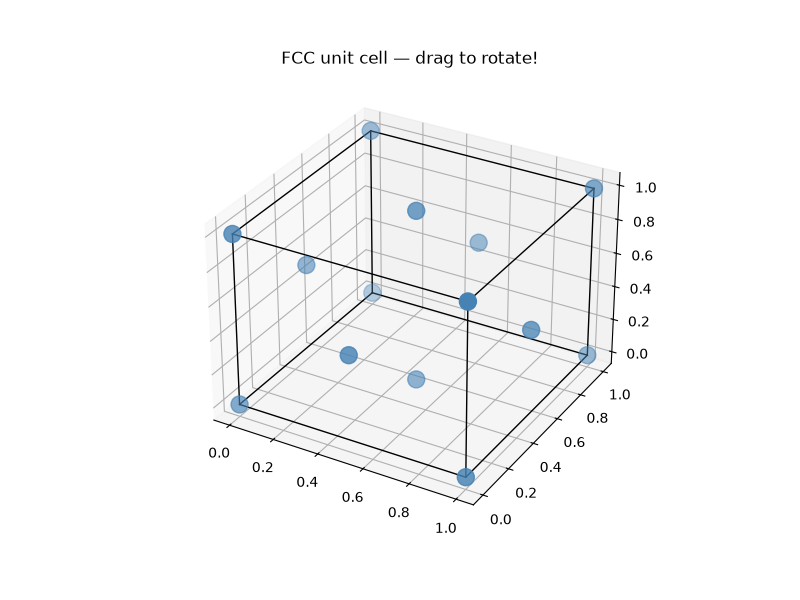

In [8]:
# OPTIONAL: enable interactive 3D rotation (Jupyter only)
try:
    get_ipython().run_line_magic("matplotlib", "widget")
    print("Interactive mode ON — drag the 3D plot to rotate it!")
except Exception:
    print("ipympl not available — run:  uv add --dev ipympl")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
atoms = unit_cell_atoms("FCC")
ax.scatter(atoms[:, 0], atoms[:, 1], atoms[:, 2], s=150, color="steelblue")
draw_cube_edges(ax)
ax.set_title("FCC unit cell — drag to rotate!")
plt.show()

## ✅ Check yourself

1. How many atoms does an FCC unit cell contain? Why 4, not 14?
2. Why is the BCC atom radius `a√3/4` and not `a/2`?
3. Which lattice has the highest packing fraction?
4. Why do we set `np.random.seed(...)` before the Monte Carlo check?

**Next:** the exercises — build your own lattice plots and submit them!